# Analisis Beban Penyakit di DKI Jakarta (2023-2025)

## Latar Belakang
Jakarta terdiri dari 6 wilayah administratif dengan karakteristik demografis berbeda. Memahami distribusi kasus penyakit antar wilayah dapat membantu identifikasi area yang membutuhkan perhatian kesehatan lebih besar.

## Problem Statement
Menganalisis distribusi dan variasi jumlah kasus penyakit menular antar wilayah administratif di DKI Jakarta periode 2023-2025, guna mengidentifikasi wilayah yang membutuhkan perhatian kesehatan masyarakat lebih besar.

## Pertanyaan Riset (Utama)
Apakah jumlah kasus tiap jenis penyakit berbeda signifikan antar wilayah di Jakarta selama periode 2023-2025?

## Rumusan Masalah (Penjabaran)
1. Jenis penyakit apa yang paling bervariasi jumlah kasusnya antar wilayah?
2. Wilayah mana yang secara konsisten punya jumlah kasus tinggi di banyak jenis penyakit?
3. Apakah ada tren naik/turun dari tahun 2023 ke 2025 untuk penyakit tertentu?
4. Apakah wilayah dengan kasus DBD tinggi juga cenderung tinggi di penyakit menular lain?

## Sumber Data
Satu Data Jakarta — Jumlah Kasus Penyakit Menurut Kabupaten/Kota dan Jenis Penyakit di Provinsi DKI Jakarta (2023-2025)

## Catatan Metodologi & Asumsi
- Data diambil dari Satu Data Jakarta. Karena tidak semua jenis penyakit memiliki label yang konsisten (kasus baru vs kumulatif), analisis difokuskan pada perbandingan antar wilayah dalam periode yang sama.
- Berdasarkan deskripsi resmi dataset di Satu Data Jakarta, hanya kategori AIDS yang secara eksplisit dibedakan menjadi “kasus baru” dan “kasus kumulatif”. Jenis penyakit lainnya (Pneumonia, TB, DBD, Difteri, Malaria, Kusta, Tetanus, Campak, IMS) tidak memiliki pembedaan serupa dalam deskripsi sumber data, sehingga diasumsikan merepresentasikan jumlah kasus pada periode berjalan (tahunan), bukan angka kumulatif.
- Ditemukan inkonsistensi penamaan kolom JUMLAH KASUS PNEUMONIA1 (2023-2024) vs JUMLAH KASUS PNEUMONIA (2025). Diasumsikan keduanya merujuk pada kategori yang sama dan telah distandarkan.
- Analisis menggunakan angka absolut kasus, bukan dinormalisasi per populasi wilayah. Hal ini merupakan keterbatasan analisis — wilayah berpenduduk lebih padat berpotensi terlihat lebih tinggi kasusnya bukan karena lebih rentan, melainkan karena jumlah penduduk lebih besar.
- Sample size per wilayah relatif kecil (3 titik data per tahun), sehingga hasil uji statistik perlu diinterpretasikan dengan hati-hati.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal

In [2]:
df = pd.read_excel(r"C:\Projecct DA\dataset.xlsx")
df.head(20)

,periode_data,wilayah,jenis_penyakit,jumlah
0,2024,KOTA ADM. JAKARTA BARAT,JUMLAH KASUS IMS,1189
1,2024,KOTA ADM. JAKARTA BARAT,JUMLAH KASUS MALARIA,34
2,2024,KOTA ADM. JAKARTA BARAT,JUMLAH KASUS TB PARU,12879
3,2024,KOTA ADM. JAKARTA BARAT,JUMLAH KASUS PNEUMONIA1,11560
4,2024,KOTA ADM. JAKARTA BARAT,JUMLAH KASUS KUSTA,69
5,2024,KOTA ADM. JAKARTA BARAT,JUMLAH KASUS TETANUS,0
6,2024,KOTA ADM. JAKARTA BARAT,TOTAL KASUS CAMPAK DKI JAKARTA,390
7,2024,KOTA ADM. JAKARTA BARAT,JUMLAH KASUS PENYAKIT DBD,3684
8,2024,KOTA ADM. JAKARTA BARAT,JUMLAH KASUS AIDS JUMLAH KASUS BARU,1095
9,2024,KOTA ADM. JAKARTA BARAT,JUMLAH KASUS AIDS JUMLAH KASUS KUMULATIF,7447


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   periode_data    180 non-null    int64 
 1   wilayah         180 non-null    object
 2   jenis_penyakit  180 non-null    object
 3   jumlah          180 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 5.8+ KB


In [4]:
df.describe()

,periode_data,jumlah
count,180.000000,180.000000
mean,2024.000000,3233.877778
std,0.818774,5304.576256
min,2023.000000,0.000000
25%,2023.000000,34.750000
50%,2024.000000,661.500000
75%,2025.000000,3709.250000
max,2025.000000,27350.000000


In [5]:
df.groupby('jenis_penyakit')['jumlah'].describe()

,count,mean,std,min,25%,50%,75%,max
jenis_penyakit,,,,,,,,
JUMLAH KASUS AIDS JUMLAH KASUS BARU,18.0,839.222222,422.696464,0.0,756.50,980.5,1119.00,1317.0
JUMLAH KASUS AIDS JUMLAH KASUS KUMULATIF,18.0,9540.000000,6804.910986,15.0,5931.00,8844.5,12678.25,27350.0
JUMLAH KASUS IMS,18.0,1160.277778,1192.778753,0.0,404.50,648.0,1807.75,3785.0
JUMLAH KASUS KUSTA,18.0,84.555556,52.062431,1.0,58.75,89.5,119.25,173.0
JUMLAH KASUS MALARIA,18.0,62.055556,52.861052,0.0,30.50,38.0,109.25,157.0
JUMLAH KASUS PENYAKIT DBD,18.0,1526.666667,1169.627693,10.0,803.25,1159.0,2584.25,3684.0
JUMLAH KASUS PNEUMONIA,6.0,13100.333333,9896.751844,252.0,5372.00,14328.5,20691.50,24494.0
JUMLAH KASUS PNEUMONIA1,12.0,6036.833333,3894.609348,0.0,4038.75,6109.0,8291.75,11560.0
JUMLAH KASUS TB PARU,18.0,10050.388889,4894.338988,46.0,10083.00,11163.0,12467.75,16040.0


In [6]:
df['wilayah'].unique()

array(['KOTA ADM. JAKARTA BARAT', 'KOTA ADM. JAKARTA PUSAT',
       'KOTA ADM. JAKARTA SELATAN', 'KOTA ADM. JAKARTA TIMUR',
       'KOTA ADM. JAKARTA UTARA', 'KAB. ADM. KEP. SERIBU'], dtype=object)

In [7]:
df['periode_data'].unique()

array([2024, 2025, 2023])

In [8]:
df['jenis_penyakit'].unique()

array(['JUMLAH KASUS IMS', 'JUMLAH KASUS MALARIA', 'JUMLAH KASUS TB PARU',
       'JUMLAH KASUS PNEUMONIA1', 'JUMLAH KASUS KUSTA',
       'JUMLAH KASUS TETANUS', 'TOTAL KASUS CAMPAK DKI JAKARTA',
       'JUMLAH KASUS PENYAKIT DBD', 'JUMLAH KASUS AIDS JUMLAH KASUS BARU',
       'JUMLAH KASUS AIDS JUMLAH KASUS KUMULATIF',
       'JUMLAH KASUS PNEUMONIA'], dtype=object)

In [9]:
df[df['jenis_penyakit'].isin(['JUMLAH KASUS PNEUMONIA1', 'JUMLAH KASUS PNEUMONIA'])].sort_values(['periode_data', 'wilayah'])

,periode_data,wilayah,jenis_penyakit,jumlah
168,2023,KAB. ADM. KEP. SERIBU,JUMLAH KASUS PNEUMONIA1,56
178,2023,KOTA ADM. JAKARTA BARAT,JUMLAH KASUS PNEUMONIA1,6427
128,2023,KOTA ADM. JAKARTA PUSAT,JUMLAH KASUS PNEUMONIA1,2544
138,2023,KOTA ADM. JAKARTA SELATAN,JUMLAH KASUS PNEUMONIA1,7567
148,2023,KOTA ADM. JAKARTA TIMUR,JUMLAH KASUS PNEUMONIA1,7741
158,2023,KOTA ADM. JAKARTA UTARA,JUMLAH KASUS PNEUMONIA1,4965
53,2024,KAB. ADM. KEP. SERIBU,JUMLAH KASUS PNEUMONIA1,0
3,2024,KOTA ADM. JAKARTA BARAT,JUMLAH KASUS PNEUMONIA1,11560
13,2024,KOTA ADM. JAKARTA PUSAT,JUMLAH KASUS PNEUMONIA1,4537
23,2024,KOTA ADM. JAKARTA SELATAN,JUMLAH KASUS PNEUMONIA1,9944


In [10]:
## saya berasumsi bahwa semenjak tahun 2025 nama kolom pneumonia1 diubah menjadi pneumonia
df[(df['jenis_penyakit'] == 'JUMLAH KASUS PNEUMONIA1') & (df['periode_data'] == 2025)]

,periode_data,wilayah,jenis_penyakit,jumlah


In [11]:
## mengubah nama kolom agar konsisten

df['jenis_penyakit'] = df['jenis_penyakit'].replace(
    'JUMLAH KASUS PNEUMONIA1', 'JUMLAH KASUS PNEUMONIA'
)

In [12]:
## mengubah dataset tsb agar lebih mudah dibaca perbandingannya sebelum analisis lebih lanjut

pivot_df = df.pivot_table(
    index=['periode_data', 'wilayah'], 
    columns='jenis_penyakit', 
    values='jumlah'
)
pivot_df

jenis_penyakit                          JUMLAH KASUS AIDS JUMLAH KASUS BARU  \
periode_data wilayah                                                          
2023         KAB. ADM. KEP. SERIBU                                      0.0   
             KOTA ADM. JAKARTA BARAT                                 1127.0   
             KOTA ADM. JAKARTA PUSAT                                 1248.0   
             KOTA ADM. JAKARTA SELATAN                               1317.0   
             KOTA ADM. JAKARTA TIMUR                                 1044.0   
             KOTA ADM. JAKARTA UTARA                                  794.0   
2024         KAB. ADM. KEP. SERIBU                                      2.0   
             KOTA ADM. JAKARTA BARAT                                 1095.0   
             KOTA ADM. JAKARTA PUSAT                                 1157.0   
             KOTA ADM. JAKARTA SELATAN                               1171.0   
             KOTA ADM. JAKARTA TIMUR                                  946.0   
             KOTA ADM. JAKARTA UTARA                                  744.0   
2025         KAB. ADM. KEP. SERIBU                                      1.0   
             KOTA ADM. JAKARTA BARAT                                  888.0   
             KOTA ADM. JAKARTA PUSAT                                 1015.0   
             KOTA ADM. JAKARTA SELATAN                               1054.0   
             KOTA ADM. JAKARTA TIMUR                                  840.0   
             KOTA ADM. JAKARTA UTARA                                  663.0   

jenis_penyakit                          JUMLAH KASUS AIDS JUMLAH KASUS KUMULATIF  \
periode_data wilayah                                                               
2023         KAB. ADM. KEP. SERIBU                                          19.0   
             KOTA ADM. JAKARTA BARAT                                     15817.0   
             KOTA ADM. JAKARTA PUSAT                                     27350.0   
             KOTA ADM. JAKARTA SELATAN                                   12020.0   
             KOTA ADM. JAKARTA TIMUR                                     14648.0   
             KOTA ADM. JAKARTA UTARA                                     12819.0   
2024         KAB. ADM. KEP. SERIBU                                          15.0   
             KOTA ADM. JAKARTA BARAT                                      7447.0   
             KOTA ADM. JAKARTA PUSAT                                     12256.0   
             KOTA ADM. JAKARTA SELATAN                                    7806.0   
             KOTA ADM. JAKARTA TIMUR                                      5521.0   
             KOTA ADM. JAKARTA UTARA                                      4536.0   
2025         KAB. ADM. KEP. SERIBU                                          18.0   
             KOTA ADM. JAKARTA BARAT                                      9837.0   
             KOTA ADM. JAKARTA PUSAT                                     16673.0   
             KOTA ADM. JAKARTA SELATAN                                    9925.0   
             KOTA ADM. JAKARTA TIMUR                                      7852.0   
             KOTA ADM. JAKARTA UTARA                                      7161.0   

jenis_penyakit                          JUMLAH KASUS IMS  JUMLAH KASUS KUSTA  \
periode_data wilayah                                                           
2023         KAB. ADM. KEP. SERIBU                   0.0                 1.0   
             KOTA ADM. JAKARTA BARAT               460.0                69.0   
             KOTA ADM. JAKARTA PUSAT               386.0               173.0   
             KOTA ADM. JAKARTA SELATAN             792.0               114.0   
             KOTA ADM. JAKARTA TIMUR               552.0               121.0   
             KOTA ADM. JAKARTA UTARA               270.0                64.0   
2024         KAB. ADM. KEP. SERIBU                   0.0                 3.0   
             KOTA 

## Pertanyaan Riset (Utama)
Apakah jumlah kasus tiap jenis penyakit berbeda signifikan antar wilayah di Jakarta selama periode 2023-2025?

### Uji Statistik: Perbandingan Antar Wilayah
Kepulauan Seribu dikecualikan dari uji statistik ini karena karakteristik 
demografis yang jauh berbeda (populasi jauh lebih kecil) dibanding 5 kota 
administrasi lainnya, sehingga dapat mendistorsi hasil uji sebagai outlier 
ekstrem. Wilayah ini tetap disertakan pada bagian eksplorasi data deskriptif 
sebelumnya.

In [13]:
df_test = df[df['wilayah'] != 'KAB. ADM. KEP. SERIBU']

hasil_test = {}
for penyakit in df_test['jenis_penyakit'].unique():
    subset = df_test[df_test['jenis_penyakit'] == penyakit]
    groups = [g['jumlah'].values for _, g in subset.groupby('wilayah')]
    stat, pval = kruskal(*groups)
    hasil_test[penyakit] = {'statistic': stat, 'p_value': pval}

hasil_df = pd.DataFrame(hasil_test).T.sort_values('p_value')
hasil_df

,statistic,p_value
JUMLAH KASUS TB PARU,13.033333,0.011114
JUMLAH KASUS KUSTA,12.923077,0.011658
JUMLAH KASUS AIDS JUMLAH KASUS BARU,10.233333,0.036675
JUMLAH KASUS MALARIA,10.193202,0.037296
JUMLAH KASUS PNEUMONIA,8.833333,0.065403
JUMLAH KASUS AIDS JUMLAH KASUS KUMULATIF,5.433333,0.245652
JUMLAH KASUS PENYAKIT DBD,4.733333,0.315769
JUMLAH KASUS IMS,1.766667,0.778575
TOTAL KASUS CAMPAK DKI JAKARTA,1.566667,0.814770
JUMLAH KASUS TETANUS,0.190963,0.995722


## Interpretasi Hasil Uji Statistik
Dari 10 jenis penyakit yang diuji, 4 penyakit menunjukkan perbedaan jumlah kasus yang signifikan antar wilayah (p-value < 0.05):

TB Paru (p=0.011)
Kusta (p=0.012)
AIDS kasus baru (p=0.037)
Malaria (p=0.037)

Sementara 6 penyakit lainnya (Pneumonia, AIDS kumulatif, DBD, IMS, Campak, Tetanus) tidak menunjukkan perbedaan yang signifikan secara statistik antar wilayah, meskipun angka mentahnya terlihat bervariasi pada tabel deskriptif sebelumnya.

Catatan: AIDS kasus baru vs kumulatif

Kedua kategori AIDS menunjukkan hasil signifikansi yang berbeda — kasus baru signifikan (p=0.037), kumulatif tidak (p=0.246). Hal ini masuk akal karena keduanya merepresentasikan rentang waktu yang berbeda: kasus baru mencerminkan kondisi tahun berjalan (2023-2025), sedangkan kumulatif adalah akumulasi kasus dari bertahun-tahun sebelumnya. Rentang waktu akumulasi yang panjang cenderung menghaluskan perbedaan antar wilayah, sehingga kasus baru lebih relevan digunakan untuk menggambarkan kondisi penyebaran AIDS saat ini.

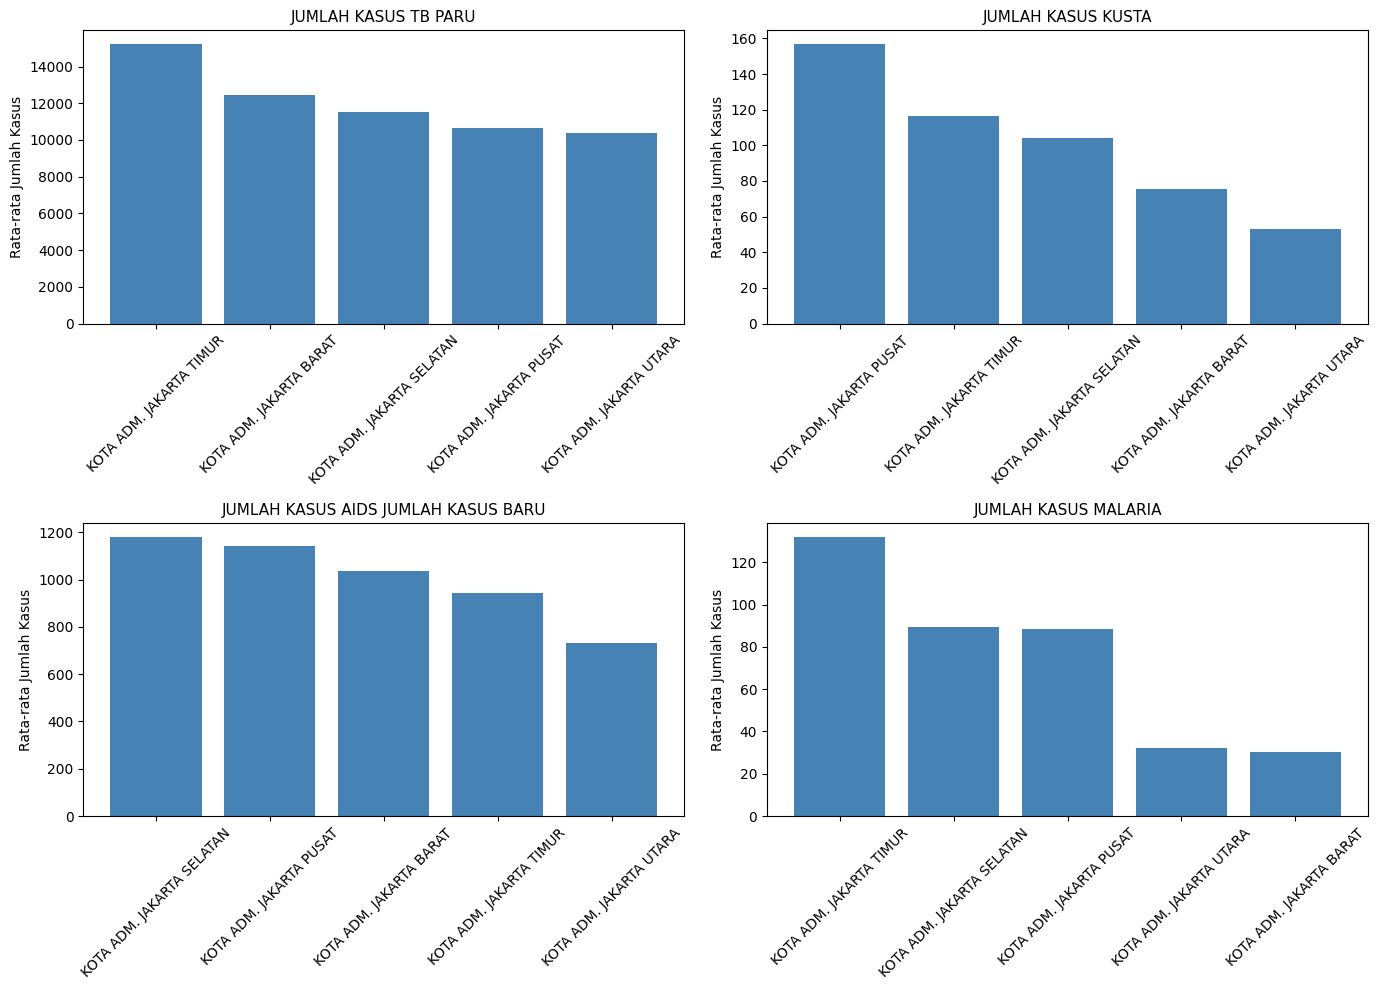

In [17]:
penyakit_signifikan = ['JUMLAH KASUS TB PARU', 'JUMLAH KASUS KUSTA', 
                         'JUMLAH KASUS AIDS JUMLAH KASUS BARU', 'JUMLAH KASUS MALARIA']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, p in enumerate(penyakit_signifikan):
    data = df_test[df_test['jenis_penyakit']==p].groupby('wilayah')['jumlah'].mean().sort_values(ascending=False)
    axes[i].bar(data.index, data.values, color='steelblue')
    axes[i].set_title(p, fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Rata-rata Jumlah Kasus')

plt.tight_layout()
plt.savefig('perbandingan_wilayah.png', dpi=150)
plt.show()

# Insight
## Pola Distribusi Antar Wilayah
Meskipun keempat penyakit (TB Paru, Kusta, AIDS kasus baru, Malaria) sama-sama terbukti signifikan secara statistik, pola persebarannya antar wilayah berbeda:
TB Paru dan AIDS kasus baru menunjukkan penurunan yang landai dari wilayah tertinggi ke terendah. Tidak ada satu wilayah yang jomplang secara ekstrem — kasus tersebar relatif proporsional di seluruh Jakarta. Ini mengindikasikan kedua penyakit ini merupakan masalah yang tersebar merata di seluruh kota, sehingga penanganannya cenderung memerlukan kebijakan menyeluruh, bukan hanya di wilayah tertentu.
Kusta dan Malaria menunjukkan pola yang berbeda — terdapat kesenjangan tajam antara wilayah tertinggi dan wilayah lainnya. Kusta terkonsentrasi tinggi di Jakarta Pusat (rata-rata 157 kasus), hampir 4 kali lipat dibanding wilayah terendah. Malaria bahkan lebih ekstrem, dengan Jakarta Timur (rata-rata 130 kasus) jauh di atas wilayah lain yang berkisar di angka puluhan. Pola ini menunjukkan adanya hotspot geografis spesifik, sehingga intervensi yang lebih tepat sasaran (targeted) di wilayah tersebut berpotensi lebih efektif dibanding kebijakan yang bersifat umum.

## Rumusan Masalah (Penjabaran)


## 1. Jenis penyakit apa yang paling bervariasi jumlah kasusnya antar wilayah?

In [20]:
df_test = df[df['wilayah'] != 'KAB. ADM. KEP. SERIBU']

hasil_test = {}
for penyakit in df_test['jenis_penyakit'].unique():
    subset = df_test[df_test['jenis_penyakit'] == penyakit]
    groups = [g['jumlah'].values for _, g in subset.groupby('wilayah')]
    stat, pval = kruskal(*groups)
    hasil_test[penyakit] = {'statistic': stat, 'p_value': pval}

hasil_df = pd.DataFrame(hasil_test).T.sort_values('p_value')
hasil_df

,statistic,p_value
JUMLAH KASUS TB PARU,13.033333,0.011114
JUMLAH KASUS KUSTA,12.923077,0.011658
JUMLAH KASUS AIDS JUMLAH KASUS BARU,10.233333,0.036675
JUMLAH KASUS MALARIA,10.193202,0.037296
JUMLAH KASUS PNEUMONIA,8.833333,0.065403
JUMLAH KASUS AIDS JUMLAH KASUS KUMULATIF,5.433333,0.245652
JUMLAH KASUS PENYAKIT DBD,4.733333,0.315769
JUMLAH KASUS IMS,1.766667,0.778575
TOTAL KASUS CAMPAK DKI JAKARTA,1.566667,0.814770
JUMLAH KASUS TETANUS,0.190963,0.995722


In [19]:
for p in penyakit_signifikan:
    print(f"\n{p}")
    print(df_test[df_test['jenis_penyakit']==p].groupby('wilayah')['jumlah'].mean().sort_values(ascending=False))


JUMLAH KASUS TB PARU
wilayah
KOTA ADM. JAKARTA TIMUR      15210.666667
KOTA ADM. JAKARTA BARAT      12472.000000
KOTA ADM. JAKARTA SELATAN    11543.333333
KOTA ADM. JAKARTA PUSAT      10641.666667
KOTA ADM. JAKARTA UTARA      10366.000000
Name: jumlah, dtype: float64

JUMLAH KASUS KUSTA
wilayah
KOTA ADM. JAKARTA PUSAT      156.666667
KOTA ADM. JAKARTA TIMUR      116.333333
KOTA ADM. JAKARTA SELATAN    104.333333
KOTA ADM. JAKARTA BARAT       75.333333
KOTA ADM. JAKARTA UTARA       53.000000
Name: jumlah, dtype: float64

JUMLAH KASUS AIDS JUMLAH KASUS BARU
wilayah
KOTA ADM. JAKARTA SELATAN    1180.666667
KOTA ADM. JAKARTA PUSAT      1140.000000
KOTA ADM. JAKARTA BARAT      1036.666667
KOTA ADM. JAKARTA TIMUR       943.333333
KOTA ADM. JAKARTA UTARA       733.666667
Name: jumlah, dtype: float64

JUMLAH KASUS MALARIA
wilayah
KOTA ADM. JAKARTA TIMUR      132.000000
KOTA ADM. JAKARTA SELATAN     89.333333
KOTA ADM. JAKARTA PUSAT       88.333333
KOTA ADM. JAKARTA UTARA       32.000000
KOTA 

## Insight
Dari keempat penyakit yang signifikan secara statistik, TB Paru menunjukkan variasi paling besar antar wilayah (statistic Kruskal-Wallis = 13.03, p-value = 0.011 — nilai terendah di antara semua penyakit yang diuji). Ini mengindikasikan TB Paru adalah penyakit yang penyebarannya paling tidak merata di Jakarta, dengan kesenjangan antara wilayah tertinggi (Jakarta Timur, rata-rata 15.211 kasus) dan terendah (Jakarta Utara, rata-rata 10.366 kasus) yang cukup besar.

## 2. Wilayah mana yang secara konsisten punya jumlah kasus tinggi di banyak jenis penyakit?

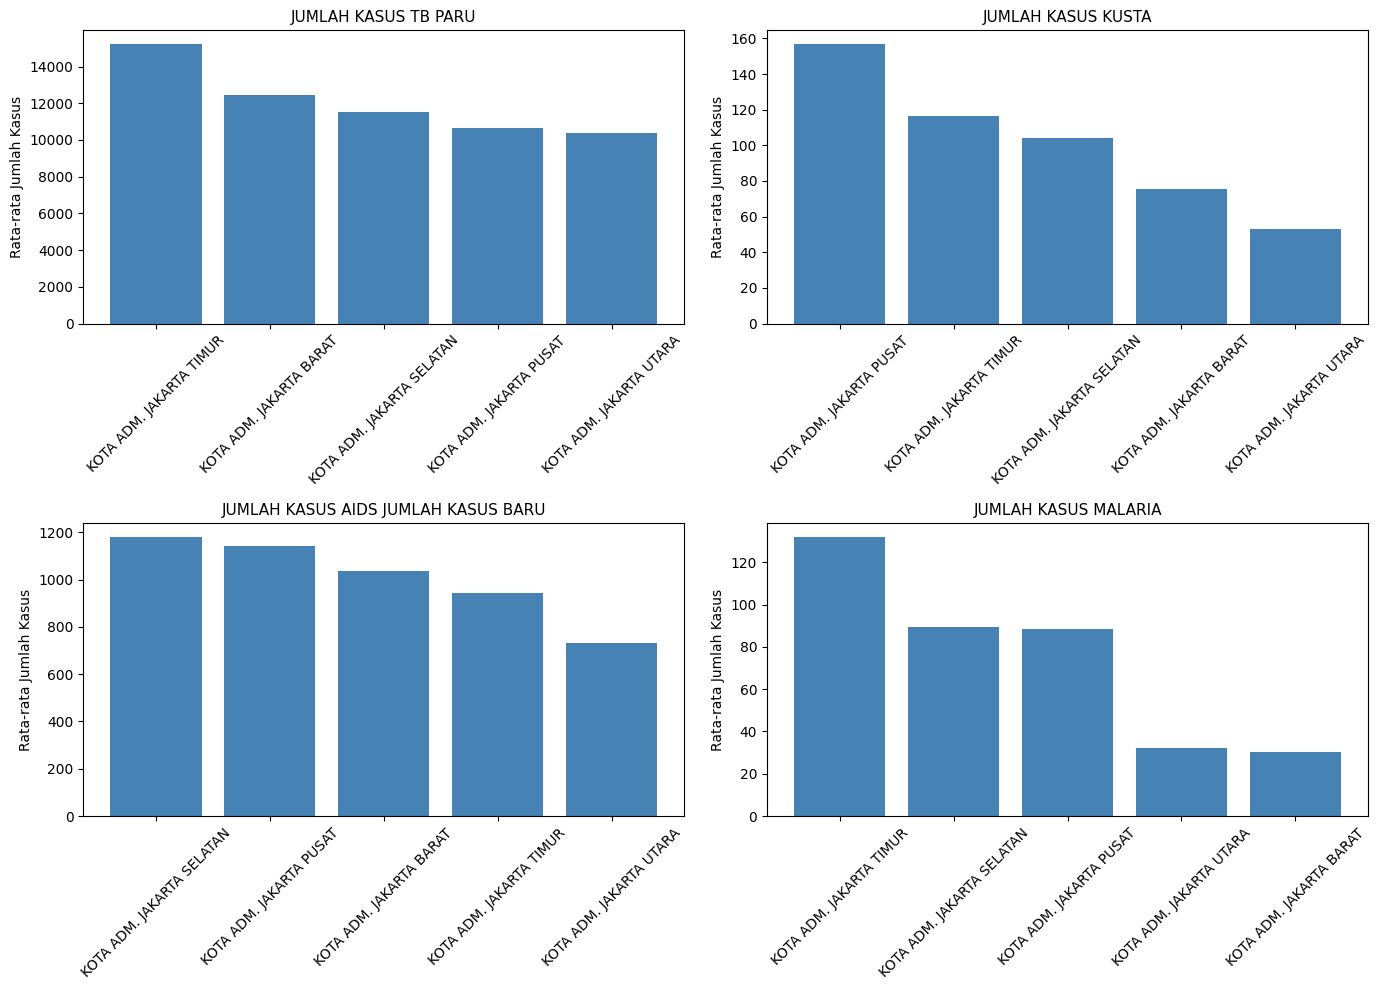

In [22]:
penyakit_signifikan = ['JUMLAH KASUS TB PARU', 'JUMLAH KASUS KUSTA', 
                         'JUMLAH KASUS AIDS JUMLAH KASUS BARU', 'JUMLAH KASUS MALARIA']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, p in enumerate(penyakit_signifikan):
    data = df_test[df_test['jenis_penyakit']==p].groupby('wilayah')['jumlah'].mean().sort_values(ascending=False)
    axes[i].bar(data.index, data.values, color='steelblue')
    axes[i].set_title(p, fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Rata-rata Jumlah Kasus')

plt.tight_layout()
plt.savefig('perbandingan_wilayah.png', dpi=150)
plt.show()

## Insight
Jakarta Timur muncul sebagai wilayah tertinggi pada 2 dari 4 penyakit signifikan (TB Paru dan Malaria), menjadikannya wilayah yang paling konsisten memiliki beban kasus tinggi dibanding wilayah lain. Sementara itu, Jakarta Pusat dan Jakarta Selatan masing-masing unggul di satu penyakit spesifik (Kusta dan AIDS), menunjukkan pola kerentanan yang lebih terlokalisasi dibanding Jakarta Timur.
Temuan ini mengindikasikan Jakarta Timur berpotensi menjadi prioritas utama untuk program kesehatan masyarakat yang menyasar penyakit menular secara umum, sementara Jakarta Pusat dan Jakarta Selatan lebih tepat menjadi sasaran intervensi spesifik sesuai jenis penyakitnya masing-masing.

## 3. Apakah ada tren naik/turun dari tahun 2023 ke 2025 untuk penyakit tertentu?

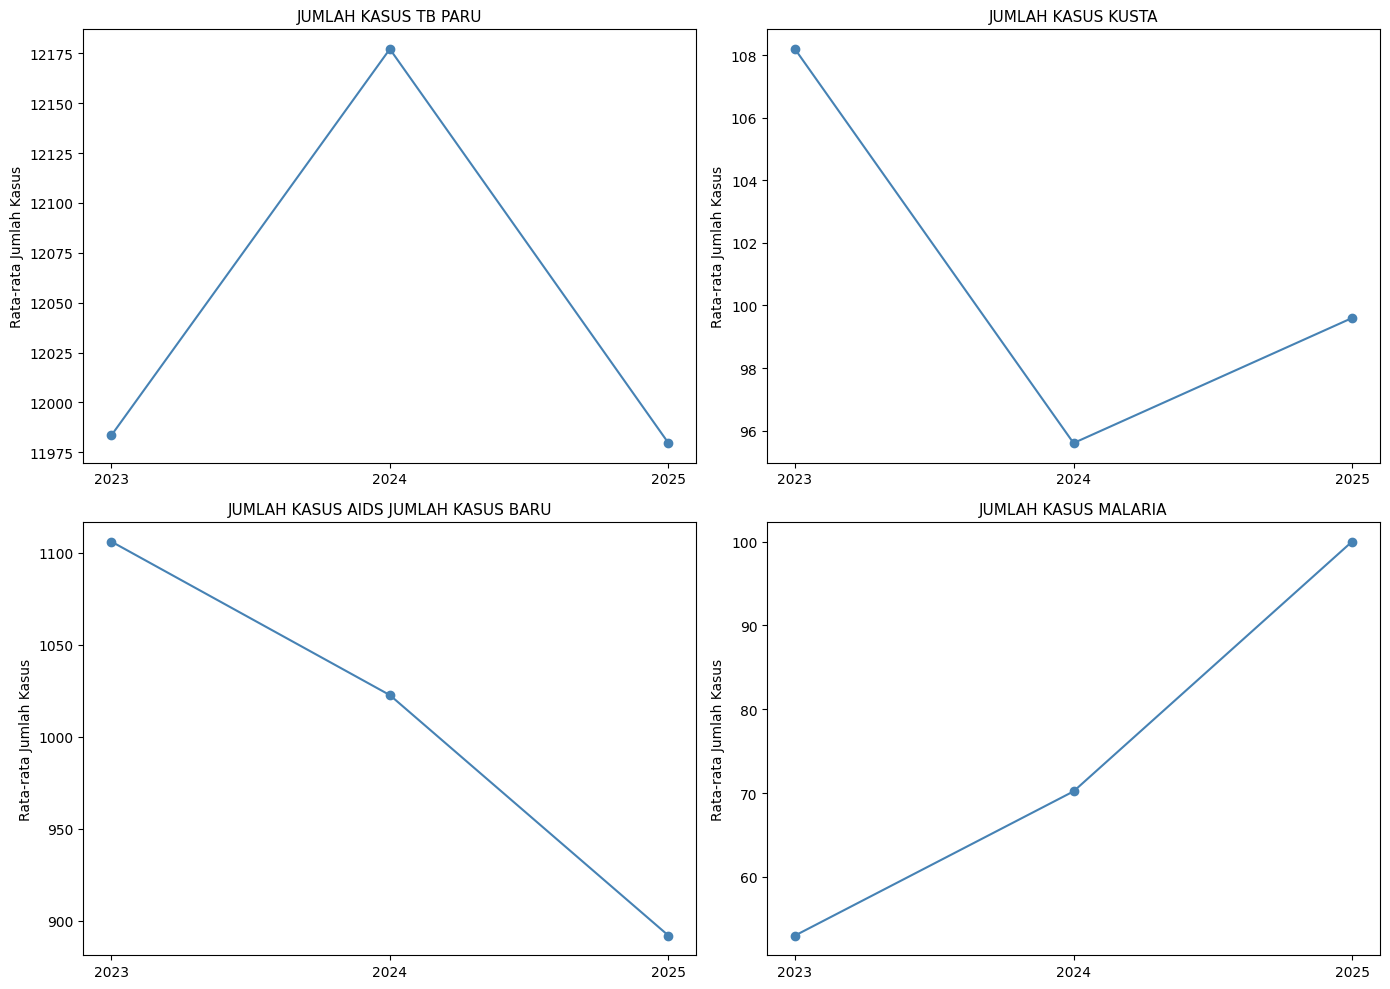

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, p in enumerate(penyakit_signifikan):
    trend = df_test[df_test['jenis_penyakit']==p].groupby('periode_data')['jumlah'].mean()
    axes[i].plot(trend.index, trend.values, marker='o', color='steelblue')
    axes[i].set_title(p, fontsize=11)
    axes[i].set_xticks([2023, 2024, 2025])
    axes[i].set_ylabel('Rata-rata Jumlah Kasus')

plt.tight_layout()
plt.savefig('tren_waktu.png', dpi=150)
plt.show()

## Insight: Tren 2023-2025
Keempat penyakit signifikan menunjukkan pola tren yang berbeda-beda selama tiga tahun terakhir:

• TB Paru dan Kusta berfluktuasi (naik-turun) tanpa arah yang konsisten, mengindikasikan kondisi yang relatif stabil dengan variasi tahunan biasa.

• AIDS kasus baru menunjukkan tren menurun konsisten dari 2023 ke 2025, sebuah sinyal positif yang dapat mengindikasikan efektivitas program pencegahan/deteksi yang berjalan.

• Malaria menunjukkan tren meningkat konsisten dan cukup tajam (hampir dua kali lipat dari 2023 ke 2025), menjadikannya penyakit yang paling perlu mendapat perhatian ke depan dari sisi tren waktu.

Pola berlawanan arah antara AIDS (menurun) dan Malaria (meningkat) menunjukkan bahwa kedua isu ini memerlukan pendekatan kebijakan yang berbeda — evaluasi keberhasilan program yang sudah ada untuk AIDS, dan investigasi lebih lanjut atas peningkatan kasus Malaria.

Catatan: tren ini didasarkan pada hanya 3 titik data per penyakit (2023, 2024, 2025), sehingga kesimpulan arah tren perlu diinterpretasikan sebagai indikasi awal, bukan kepastian statistik.

## 4. Apakah wilayah dengan kasus DBD tinggi juga cenderung tinggi di penyakit menular lain?

Catatan: Rumusan Masalah #4 (Korelasi DBD)

Rumusan masalah mengenai korelasi antara kasus DBD dengan penyakit menular lain tidak dieksplorasi lebih lanjut pada analisis ini. Hal ini karena DBD sendiri terbukti tidak signifikan secara statistik pada uji Kruskal-Wallis (p=0.316), sehingga analisis korelasi lanjutan terhadapnya dinilai kurang relevan dengan temuan utama dan arah insight yang dibangun (yang berfokus pada empat penyakit dengan variasi signifikan antar wilayah). Eksplorasi ini dapat menjadi bahan pengembangan lanjutan di luar cakupan proyek saat ini.

# Kesimpulan
Menjawab pertanyaan riset utama: Ya, jumlah kasus penyakit terbukti berbeda signifikan antar wilayah di Jakarta — namun hanya untuk 4 dari 10 jenis penyakit yang diuji: TB Paru, Kusta, AIDS kasus baru, dan Malaria (p-value < 0.05). Enam penyakit lainnya (Pneumonia, AIDS kumulatif, DBD, IMS, Campak, Tetanus) tidak menunjukkan perbedaan yang signifikan secara statistik antar wilayah.
Ringkasan temuan utama:

1. TB Paru memiliki variasi antar wilayah paling besar, dengan pola persebaran yang landai (tidak ada wilayah yang jomplang ekstrem) — mengindikasikan masalah yang tersebar merata di seluruh Jakarta.
2. Kusta dan Malaria menunjukkan pola hotspot — terkonsentrasi tajam di satu wilayah (Kusta di Jakarta Pusat, Malaria di Jakarta Timur), cocok untuk intervensi yang tertarget.
3. Jakarta Timur adalah wilayah yang paling konsisten memiliki beban kasus tinggi, muncul sebagai wilayah tertinggi pada 2 dari 4 penyakit signifikan (TB Paru dan Malaria).
4. Dari sisi tren 2023-2025, AIDS kasus baru menurun konsisten sementara Malaria meningkat konsisten — dua arah yang berlawanan dan sama-sama perlu perhatian, meski dengan pendekatan kebijakan yang berbeda.

## Rekomendasi:

- Jakarta Timur dapat menjadi prioritas program kesehatan masyarakat yang bersifat umum/menyeluruh, mengingat konsistensinya di berbagai penyakit.
- Jakarta Pusat (Kusta) dan Jakarta Timur (Malaria) berpotensi diuntungkan dari intervensi yang lebih tertarget dan spesifik.
- Peningkatan tren Malaria perlu diinvestigasi lebih lanjut untuk memahami penyebabnya.

## Keterbatasan analisis:

- Analisis menggunakan angka kasus absolut, bukan dinormalisasi terhadap jumlah penduduk per wilayah, sehingga wilayah dengan populasi lebih besar berpotensi tampak lebih tinggi kasusnya bukan karena lebih rentan.
- Kepulauan Seribu dikecualikan dari uji statistik karena karakteristik demografis yang jauh berbeda dari 5 wilayah lain.
- Sample size relatif kecil (3 titik data per tahun per wilayah), sehingga hasil uji statistik dan tren waktu perlu diinterpretasikan sebagai indikasi awal.
- Rumusan masalah mengenai korelasi DBD dengan penyakit lain tidak dieksplorasi karena DBD tidak signifikan pada uji statistik utama.


